E-commerce Customer Segmentation & Prediction (RFM + ML)


NOTEBOOK STRUCTURE

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Visualization
5. RFM Visualization
6. PreProcessing
7. Clustering Models
8. Target Variable Creation
9. Train-Test Split
10. ML Models Training
11. Model Evaluation
12. Final Conclusion


🔷 STEP 1 — IMPORT LIBRARIES

In [258]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

🔷 STEP 2 — LOAD DATASETS

In [259]:
retail = pd.read_csv(r"D:\Capstone Project\EXCEL\Online_Retail_Cleaned.csv")
rfm = pd.read_csv(r"D:\Capstone Project\SQL\sql exports in CSV\rfm_segment.csv")
ml = pd.read_csv(r"D:\Capstone Project\SQL\sql exports in CSV\ml_features.csv")


🔷 STEP 3 — BASIC DATA UNDERSTANDING (EDA)

In [260]:
retail.shape
retail.info()
retail.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     392692 non-null  int64  
 1   StockCode     392692 non-null  object 
 2   Description   392692 non-null  object 
 3   Quantity      392692 non-null  int64  
 4   InvoiceDate   392692 non-null  object 
 5   UnitPrice     392692 non-null  float64
 6   CustomerID    392692 non-null  int64  
 7   Country       392692 non-null  object 
 8   Total Amount  392692 non-null  float64
 9   Year          392692 non-null  int64  
 10  Month         392692 non-null  object 
 11  Day           392692 non-null  int64  
 12  Hour          392692 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 38.9+ MB


,InvoiceNo,Quantity,UnitPrice,CustomerID,Total Amount,Year,Day,Hour
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500,2010.934631,15.704450,12.721532
std,13087.063759,180.492832,22.241836,1713.539549,311.099224,0.247177,8.047327,2.276661
min,536365.000000,1.000000,0.001000,12346.000000,0.001000,2010.000000,1.000000,6.000000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000,2011.000000,10.000000,11.000000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000,2011.000000,15.000000,13.000000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000,2011.000000,22.000000,14.000000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000,2011.000000,31.000000,20.000000


In [261]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850,United Kingdom,15.30,2010,Jan-10,12,8
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850,United Kingdom,20.34,2010,Jan-10,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850,United Kingdom,22.00,2010,Jan-10,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850,United Kingdom,20.34,2010,Jan-10,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850,United Kingdom,20.34,2010,Jan-10,12,8


In [262]:
retail.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,Month,Day,Hour
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-2011 12:50,0.85,12680,France,10.20,2011,Sep-11,12,12
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-2011 12:50,2.10,12680,France,12.60,2011,Sep-11,12,12
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12:50,4.15,12680,France,16.60,2011,Sep-11,12,12
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12:50,4.15,12680,France,16.60,2011,Sep-11,12,12
392691,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12-09-2011 12:50,4.95,12680,France,14.85,2011,Sep-11,12,12


In [263]:
rfm.shape

(4338, 9)

In [264]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Total,Segment
0,16738,299,1,3.75,1,1,1,3,Low Value
1,14792,154,1,6.20,2,1,1,4,Low Value
2,16454,46,2,6.90,3,3,1,7,Potential
3,17956,251,1,12.75,1,1,1,3,Low Value
4,16878,86,1,13.30,3,2,1,6,At Risk


In [265]:
rfm.info()
rfm.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      4338 non-null   int64  
 1   Recency         4338 non-null   int64  
 2   Frequency       4338 non-null   int64  
 3   Monetary        4338 non-null   float64
 4   RecencyScore    4338 non-null   int64  
 5   FrequencyScore  4338 non-null   int64  
 6   MonetaryScore   4338 non-null   int64  
 7   RFM_Total       4338 non-null   int64  
 8   Segment         4338 non-null   object 
dtypes: float64(1), int64(7), object(1)
memory usage: 305.1+ KB


,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Total
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,106.502766,4.272015,2055.936791,2.999308,2.999308,2.999308,8.997925
std,1721.808492,115.089552,7.697998,9003.803424,1.414295,1.414295,1.414295,3.658748
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.000000,1.000000,3.000000
25%,13813.250000,23.000000,1.000000,307.167500,2.000000,2.000000,2.000000,6.000000
50%,15299.500000,62.000000,2.000000,674.485000,3.000000,3.000000,3.000000,9.000000
75%,16778.750000,162.750000,5.000000,1661.345000,4.000000,4.000000,4.000000,12.000000
max,18287.000000,698.000000,209.000000,280206.020000,5.000000,5.000000,5.000000,15.000000


In [266]:
ml.shape

(4338, 4)

In [267]:
ml.info()
ml.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,106.502766,4.272015,2055.936791
std,1721.808492,115.089552,7.697998,9003.803424
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,23.000000,1.000000,307.167500
50%,15299.500000,62.000000,2.000000,674.485000
75%,16778.750000,162.750000,5.000000,1661.345000
max,18287.000000,698.000000,209.000000,280206.020000


In [268]:
ml.head()   

,CustomerID,Recency,Frequency,Monetary
0,12346,327,1,77183.60
1,12347,41,7,4310.00
2,12348,77,4,1797.24
3,12349,20,1,1757.55
4,12350,312,1,334.40


🔷 STEP 4 — EDA VISUALIZATION


📊 4.1 Revenue Distribution

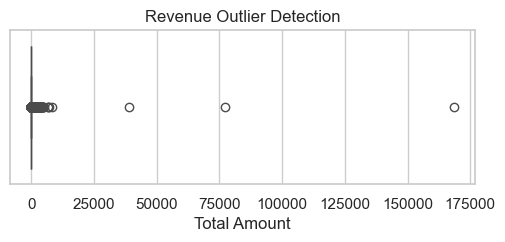

In [269]:
plt.figure(figsize=(6,2))
sns.boxplot(x=retail['Total Amount'])
plt.title("Revenue Outlier Detection")
plt.show()


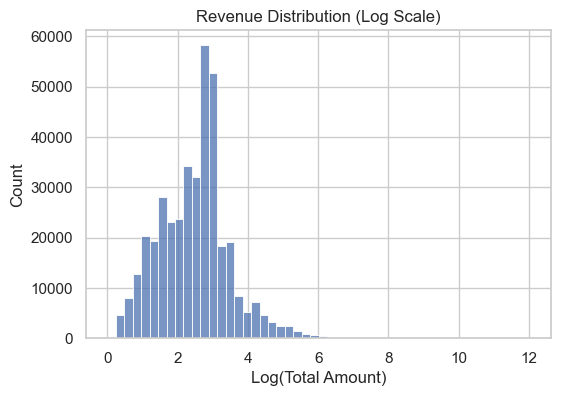

In [270]:
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(retail['Total Amount']), bins=50)
plt.title("Revenue Distribution (Log Scale)")
plt.xlabel("Log(Total Amount)")
plt.show()


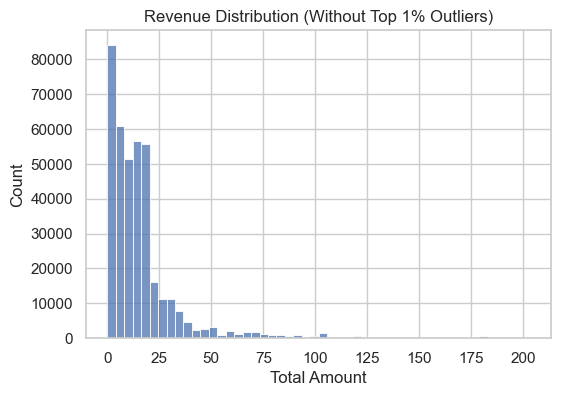

In [271]:
filtered = retail[retail['Total Amount'] < retail['Total Amount'].quantile(0.99)]

plt.figure(figsize=(6,4))
sns.histplot(filtered['Total Amount'], bins=50)
plt.title("Revenue Distribution (Without Top 1% Outliers)")
plt.show()


Insight:
Most orders are small; few high-value orders dominate revenue.

📊 4.2 Monthly Revenue Trend

In [272]:
# Convert InvoiceDate to datetime (safe conversion)
retail['InvoiceDate'] = pd.to_datetime(
    retail['InvoiceDate'],
    errors='coerce',
    dayfirst=True
)

# Create Month column
retail['Month'] = retail['InvoiceDate'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = retail.groupby('Month')['Total Amount'].sum()


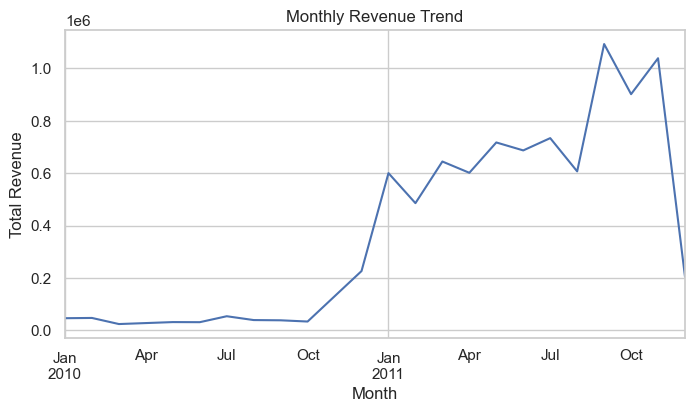

In [273]:
monthly_revenue.plot(figsize=(8,4))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

Insight:
Shows seasonality and growth patterns.

📊 4.3 Top Countries by Revenue

In [274]:
top_countries = (
    retail.groupby('Country')['Total Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


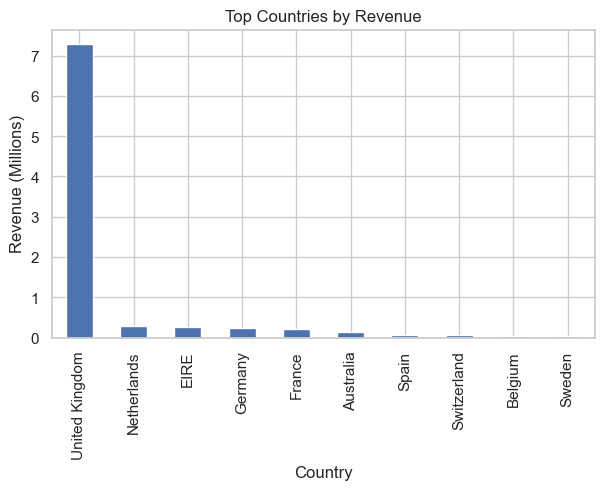

In [275]:
(top_countries / 1_000_000).plot(kind='bar', figsize=(7,4))
plt.ylabel("Revenue (Millions)")
plt.title("Top Countries by Revenue")
plt.show()


In [276]:
top_product = (
    retail.groupby('Description')['Total Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


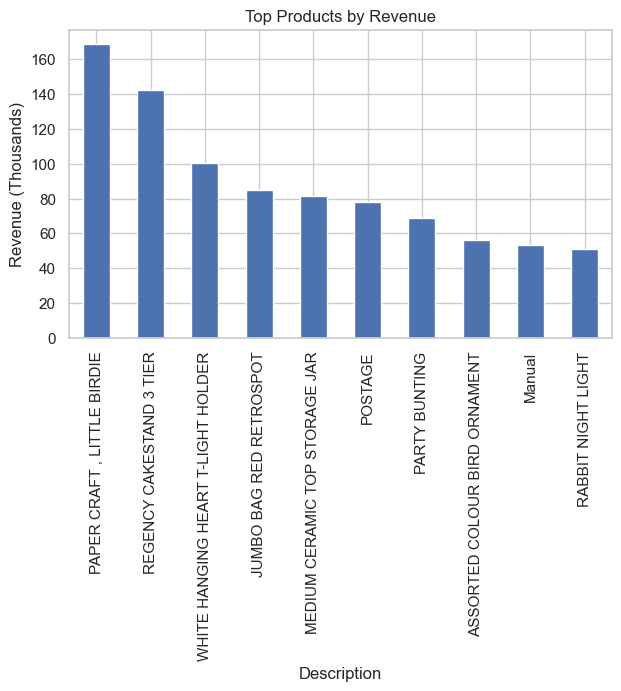

In [277]:
(top_product / 1_000).plot(kind='bar', figsize=(7,4))
plt.ylabel("Revenue (Thousands)")
plt.title("Top Products by Revenue")
plt.show()

🔷 STEP 5 — RFM FEATURE ENGINEERING (PYTHON)

5.1 Load/Check data

In [278]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30,2010,2010-01,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-01,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00,2010,2010-01,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-01,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-01,12,8


5.2 Ensure correct data type

In [279]:
# Convert InvoiceDate to datetime (important for recency calculation)
retail['InvoiceDate'] = pd.to_datetime(
    retail['InvoiceDate'],
    errors='coerce',      # handles mixed formats safely
    dayfirst=True         # matches your SQL date logic
)


5.3 Apply filters

In [280]:
# Apply same filters as SQL
retail = retail[
    (retail['CustomerID'].notna()) &
    (retail['Quantity'] > 0) &
    (retail['UnitPrice'] > 0) &
    (~retail['InvoiceNo'].astype(str).str.startswith('C'))
]


5.4 Define snapshot date

In [281]:
# Snapshot date = last invoice date + 1 day
snapshot_date = retail['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date


Timestamp('2011-12-11 17:19:00')

5.5 Create RFM Base table

In [282]:
rfm_base = retail.groupby('CustomerID').agg({
    'InvoiceDate': [
        lambda x: (snapshot_date - x.max()).days,   # Recency
        'min',                                      # FirstPurchaseDate
        'max'                                       # LastPurchaseDate
    ],
    'InvoiceNo': 'nunique',                         # Frequency
    'Total Amount': 'sum'                           # Monetary
}).reset_index()


In [283]:
rfm_base.columns = [
    'CustomerID',
    'Recency',
    'FirstPurchaseDate',
    'LastPurchaseDate',
    'Frequency',
    'Monetary'
]

rfm_base['Monetary'] = rfm_base['Monetary'].round(2)


🔥 RFM Heatmap (Recency vs Frequency)

C:\Users\visha\AppData\Local\Temp\ipykernel_10664\1138051632.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_rfm = rfm_base.pivot_table(


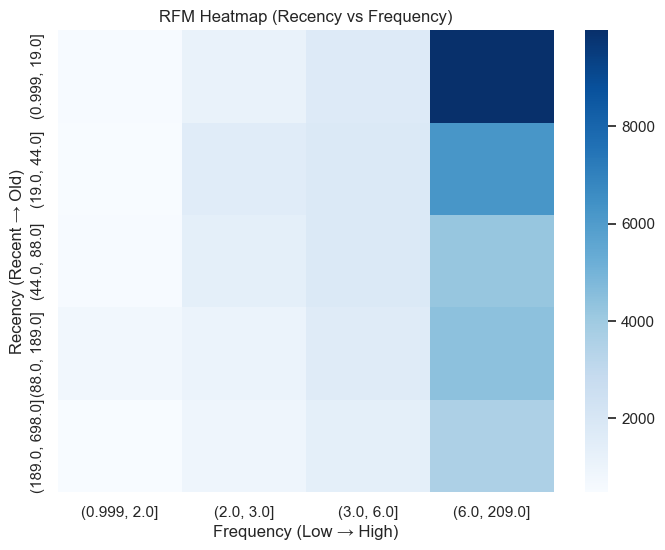

In [284]:
pivot_rfm = rfm_base.pivot_table(
    index=pd.qcut(rfm_base['Recency'], 5, duplicates='drop'),
    columns=pd.qcut(rfm_base['Frequency'], 5, duplicates='drop'),
    values='Monetary',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_rfm, cmap='Blues')
plt.title("RFM Heatmap (Recency vs Frequency)")
plt.xlabel("Frequency (Low → High)")
plt.ylabel("Recency (Recent → Old)")
plt.show()


Insight:
Customers who purchase frequently and recently contribute disproportionately higher revenue, validating the High-Value and Loyal segments

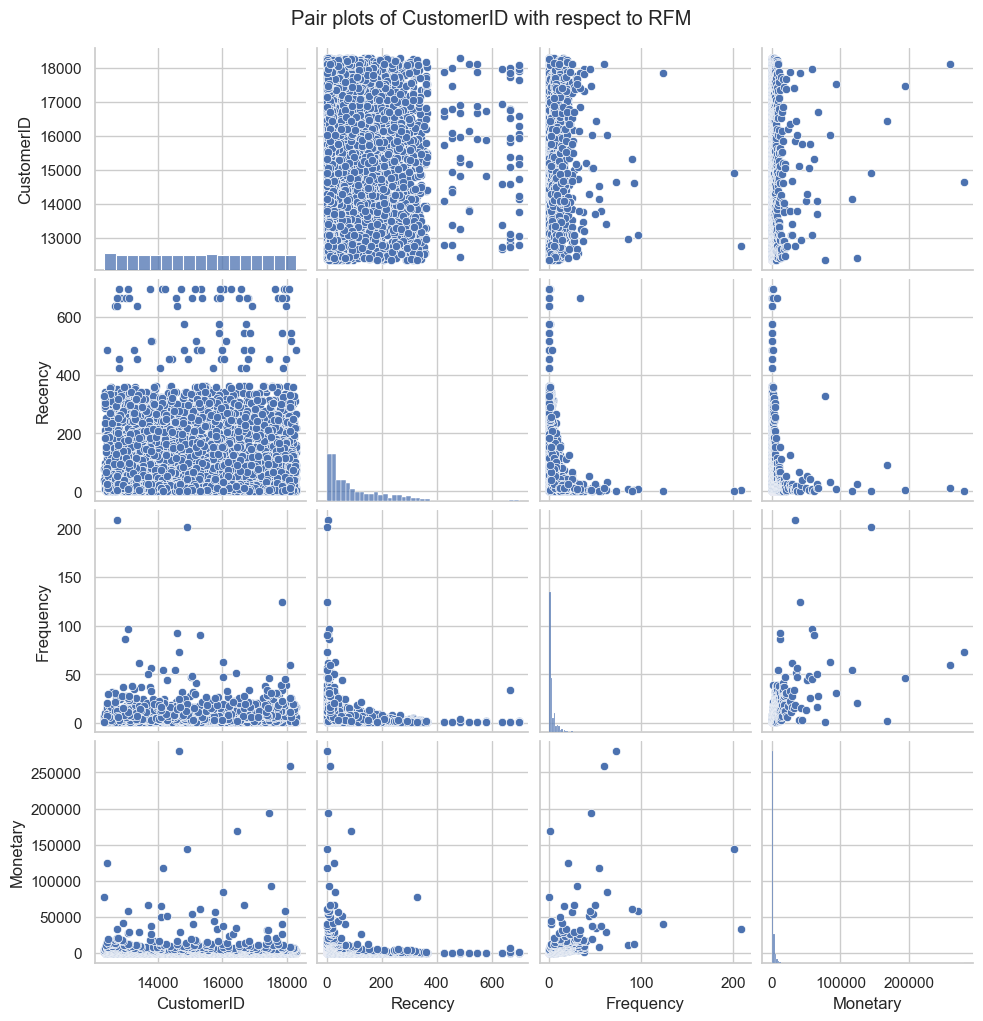

In [285]:
pairplot_df = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

sns.pairplot(pairplot_df)
plt.suptitle("Pair plots of CustomerID with respect to RFM", y=1.02)
plt.show()


5.6 RFM Scoring (1-5)

In [286]:
rfm_scored = rfm_base.copy()

rfm_scored['RecencyScore'] = pd.qcut(
    rfm_scored['Recency'], 5, labels=[5,4,3,2,1]
).astype(int)

rfm_scored['FrequencyScore'] = pd.qcut(
    rfm_scored['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]
).astype(int)

rfm_scored['MonetaryScore'] = pd.qcut(
    rfm_scored['Monetary'], 5, labels=[1,2,3,4,5]
).astype(int)


5.7 RFM Segments

In [287]:

rfm_scored['RFM_Total'] = (
    rfm_scored['RecencyScore'] +
    rfm_scored['FrequencyScore'] +
    rfm_scored['MonetaryScore']
)

rfm_scored['Segment'] = np.select(
    [
        rfm_scored['RFM_Total'] >= 13,
        rfm_scored['RFM_Total'].between(10, 12),
        rfm_scored['RFM_Total'].between(7, 9),
        rfm_scored['RFM_Total'].between(5, 6)
    ],
    [
        'High Value',
        'Loyal',
        'Potential',
        'At Risk'
    ],
    default='Low Value'
)


Segment-wise Revenue Bar Chart

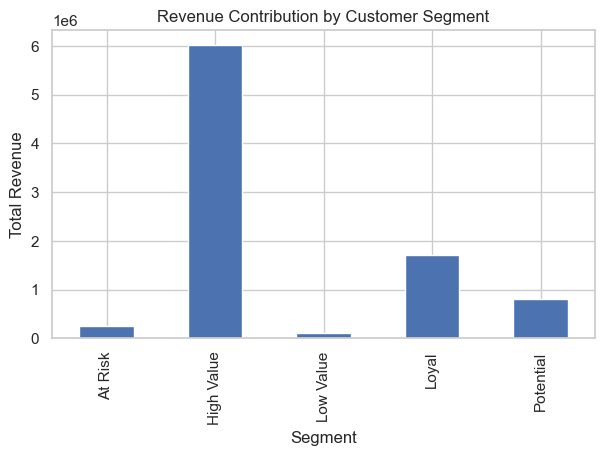

In [288]:
segment_revenue = rfm_scored.groupby('Segment')['Monetary'].sum()

segment_revenue.plot(kind='bar', figsize=(7,4))
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Revenue")
plt.show()


5.8 Save for ML

In [289]:
rfm_scored.to_csv("rfm_segments_python.csv", index=False)


🔷 STEP 6 - PreProcessing

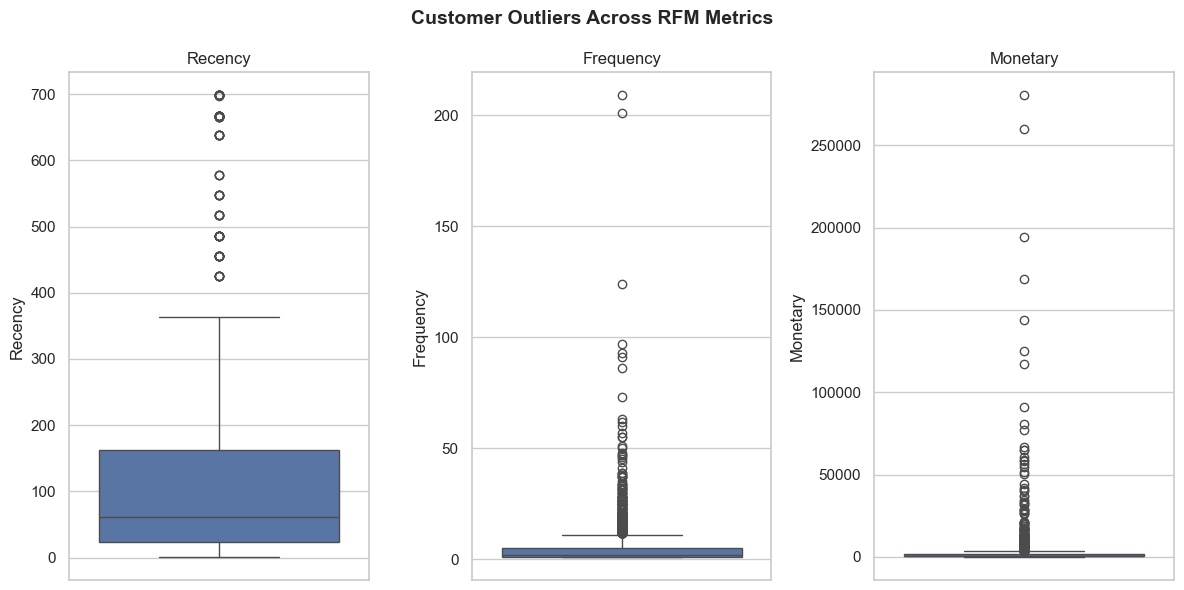

In [290]:
# STEP 6.1 - OUTLIERS HANDLING


plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(y=rfm_base["Recency"])
plt.title("Recency")

plt.subplot(1,3,2)
sns.boxplot(y=rfm_base["Frequency"])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.boxplot(y=rfm_base["Monetary"])
plt.title("Monetary")

plt.suptitle("Customer Outliers Across RFM Metrics", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


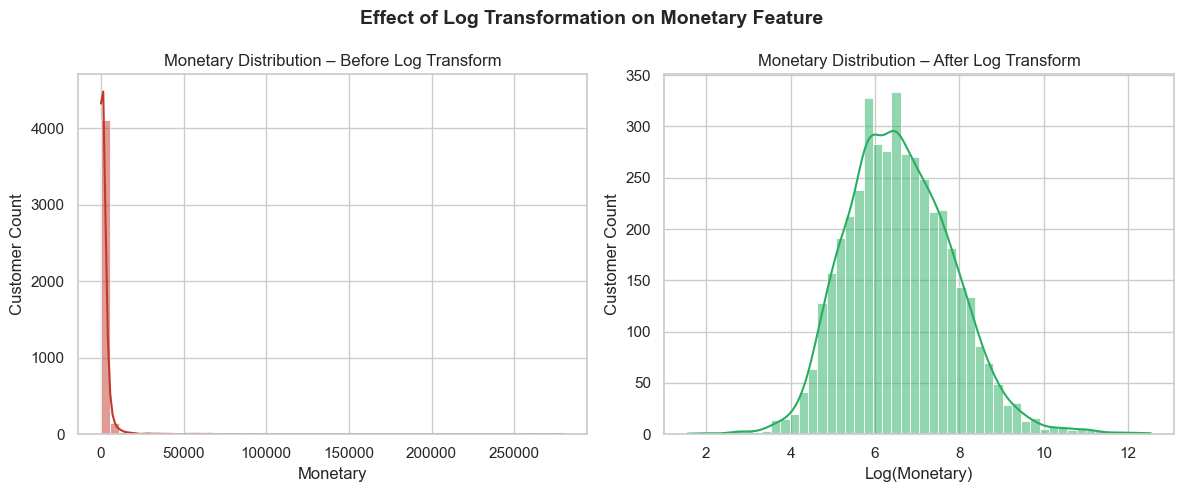

In [291]:
# STEP 6.2 - LOG TRANSFORMATION

#STEP 6.2.1 - Monetary log transformation


import numpy as np

# Add 1 to avoid log(0) issue
rfm_base["Monetary_log"] = np.log1p(rfm_base["Monetary"])

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,5))

# BEFORE log transform
plt.subplot(1,2,1)
sns.histplot(rfm_base["Monetary"], bins=50, kde=True, color="#C0392B")
plt.title("Monetary Distribution – Before Log Transform")
plt.xlabel("Monetary")
plt.ylabel("Customer Count")

# AFTER log transform
plt.subplot(1,2,2)
sns.histplot(rfm_base["Monetary_log"], bins=50, kde=True, color="#27AE60")
plt.title("Monetary Distribution – After Log Transform")
plt.xlabel("Log(Monetary)")
plt.ylabel("Customer Count")

plt.suptitle("Effect of Log Transformation on Monetary Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


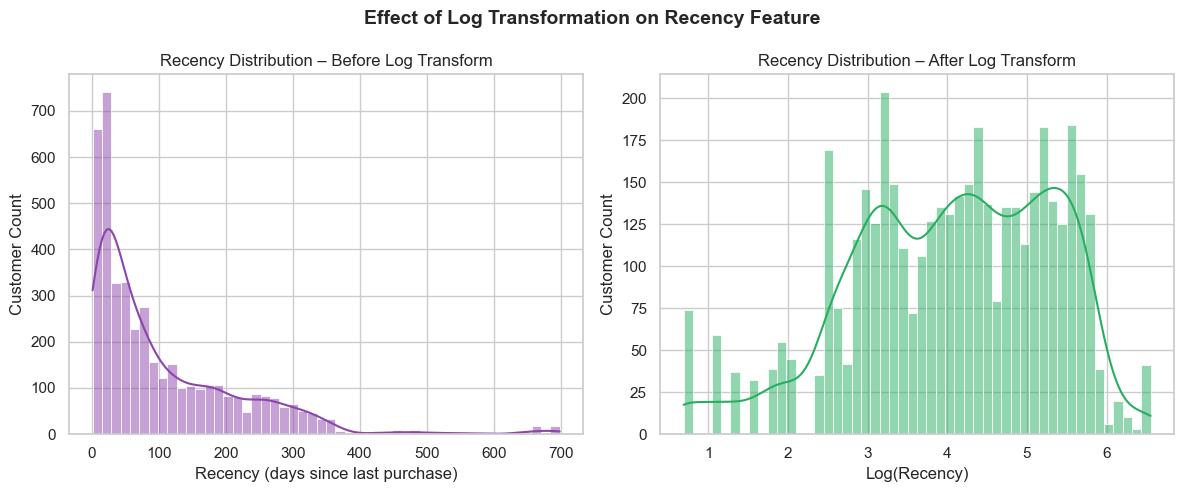

In [292]:
#STEP 6.2.2 - Recency Log Transformation


# add 1 to avoid log(0)
rfm_base["Recency_log"] = np.log1p(rfm_base["Recency"])

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,5))

# BEFORE transform
plt.subplot(1,2,1)
sns.histplot(rfm_base["Recency"], bins=50, kde=True, color="#8E44AD")
plt.title("Recency Distribution – Before Log Transform")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Customer Count")

# AFTER transform
plt.subplot(1,2,2)
sns.histplot(rfm_base["Recency_log"], bins=50, kde=True, color="#27AE60")
plt.title("Recency Distribution – After Log Transform")
plt.xlabel("Log(Recency)")
plt.ylabel("Customer Count")

plt.suptitle("Effect of Log Transformation on Recency Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


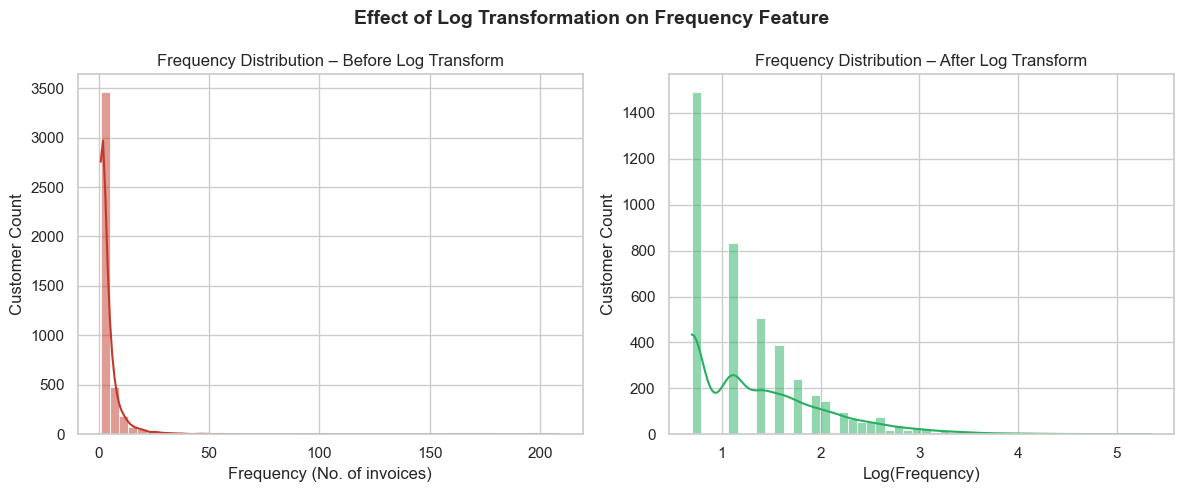

In [293]:
#STEP 6.2.3 - Frequency Log Transformation

rfm_base["Frequency_log"] = np.log1p(rfm_base["Frequency"])

plt.figure(figsize=(12,5))

# BEFORE
plt.subplot(1,2,1)
sns.histplot(rfm_base["Frequency"], bins=50, kde=True, color="#C0392B")
plt.title("Frequency Distribution – Before Log Transform")
plt.xlabel("Frequency (No. of invoices)")
plt.ylabel("Customer Count")

# AFTER
plt.subplot(1,2,2)
sns.histplot(rfm_base["Frequency_log"], bins=50, kde=True, color="#27AE60")
plt.title("Frequency Distribution – After Log Transform")
plt.xlabel("Log(Frequency)")
plt.ylabel("Customer Count")

plt.suptitle("Effect of Log Transformation on Frequency Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [294]:
# STEP 6.3 - FEATURE SCALING

from sklearn.preprocessing import StandardScaler


# Select only RFM numeric features
rfm_features = rfm_base[['Recency', 'Frequency', 'Monetary']]

# Initialize scaler
scaler = StandardScaler()

# Fit + transform
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame for readability
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
    index=rfm_base.index
)

rfm_scaled_df.head()


,Recency_scaled,Frequency_scaled,Monetary_scaled
0,1.916496,-0.425097,8.363010
1,-0.568972,0.354417,0.251699
2,-0.256116,-0.035340,-0.027988
3,-0.751471,-0.425097,-0.032406
4,1.786139,-0.425097,-0.190812


🔷 STEP 7 — CLUSTERING MODELS (Customer Segmentation)

K-MEANS:

Works best on scaled numeric data.

Fast & interpretable.

Industry standard for customer segmentation.

Easy mapping to High / Loyal / Potential / At Risk.

7.1 - Deciding number of cluster (K)

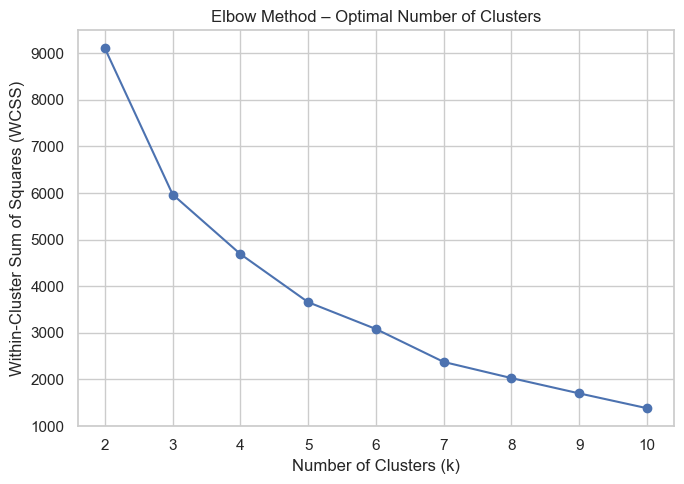

In [295]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = rfm_base[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []  # Within-cluster sum of squares

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method – Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True)
plt.tight_layout()
plt.show()


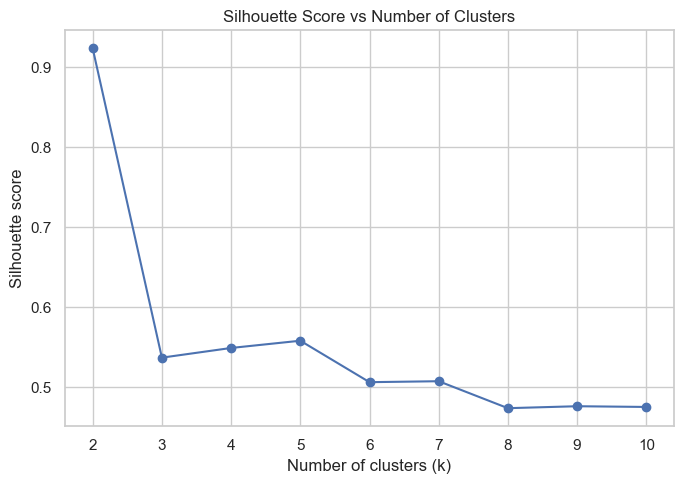

In [296]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

#Plot Silhouette Curve
plt.figure(figsize=(7,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)

plt.tight_layout()
plt.savefig("silhouette_score_600dpi.png", dpi=600)
plt.show()


7.2 Apply K-means Clustering

In [297]:
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

rfm_base['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

rfm_base.head()


,CustomerID,Recency,FirstPurchaseDate,LastPurchaseDate,Frequency,Monetary,Monetary_log,Recency_log,Frequency_log,Cluster
0,12346,327,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,11.253955,5.793014,0.693147,0
1,12347,41,2010-07-12 14:57:00,2011-10-31 12:25:00,7,4310.00,8.368925,3.737670,2.079442,2
2,12348,77,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,7.494564,4.356709,1.609438,2
3,12349,20,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,7.472245,3.044522,0.693147,2
4,12350,312,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,5.815324,5.746203,0.693147,4


7.3 CLUSTER INTERPRETATION

In [298]:
cluster_summary = (
    rfm_base
    .groupby('Cluster')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,21.42,16.47,7879.03
1,22.20,76.40,209287.56
2,55.45,3.30,1192.40
3,13.43,64.05,56430.49
4,270.66,1.55,493.82


7.4 Cluster wise revenue bar chart

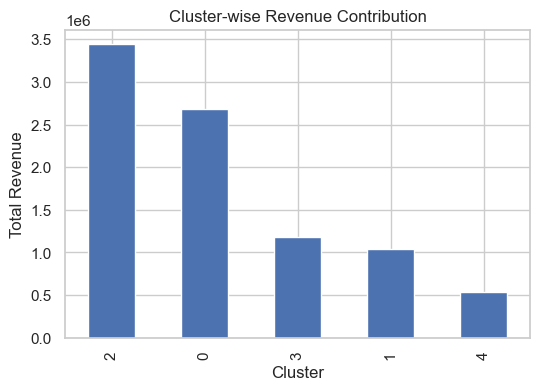

In [299]:
cluster_revenue = (
    rfm_base
    .groupby('Cluster')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
cluster_revenue.plot(kind='bar')
plt.title("Cluster-wise Revenue Contribution")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.show()


Insight: A small number of clusters contribute the majority of revenue, indicating strong revenue concentration.

7.5 - Map clusters to segments

In [300]:
# Rank clusters by Monetary value
cluster_rank = (
    rfm_base.groupby('Cluster')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

cluster_rank


Cluster
1    209287.556000
3     56430.488095
0      7879.030147
2      1192.401106
4       493.820994
Name: Monetary, dtype: float64

In [301]:
cluster_map = {
    cluster_rank.index[0]: 'High Value',
    cluster_rank.index[1]: 'Loyal',
    cluster_rank.index[2]: 'Potential',
    cluster_rank.index[3]: 'At Risk',
    cluster_rank.index[4]: 'Low Value'
}

rfm_base['Segment'] = rfm_base['Cluster'].map(cluster_map)


In [302]:
rfm_base['Segment'].value_counts()


Segment
At Risk       2885
Low Value     1087
Potential      340
Loyal           21
High Value       5
Name: count, dtype: int64

HIERARCHICAL CLUSTERING:

Builds clusters step-by-step

Does not require K upfront

Produces a tree structure (dendrogram)

Helps validate K-Means choice

7.6 - Create Dendogram

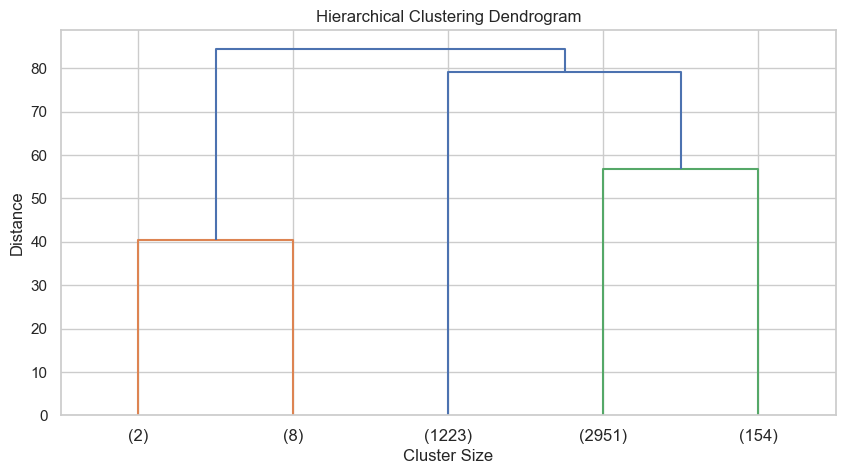

In [303]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix
linked = linkage(rfm_scaled_df, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


7.7 - Apply Hierarchical clustering

In [304]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=5)

rfm_base['Hierarchical_Cluster'] = hierarchical.fit_predict(rfm_scaled_df)

rfm_base.head()


,CustomerID,Recency,FirstPurchaseDate,LastPurchaseDate,Frequency,Monetary,Monetary_log,Recency_log,Frequency_log,Cluster,Segment,Hierarchical_Cluster
0,12346,327,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,11.253955,5.793014,0.693147,0,Potential,1
1,12347,41,2010-07-12 14:57:00,2011-10-31 12:25:00,7,4310.00,8.368925,3.737670,2.079442,2,At Risk,3
2,12348,77,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,7.494564,4.356709,1.609438,2,At Risk,3
3,12349,20,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,7.472245,3.044522,0.693147,2,At Risk,3
4,12350,312,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,5.815324,5.746203,0.693147,4,Low Value,0


7.8 - Interpret hierarchical clusters

In [305]:
hier_summary = (
    rfm_base
    .groupby('Hierarchical_Cluster')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(2)
)

hier_summary


,Recency,Frequency,Monetary
Hierarchical_Cluster,,,
0,257.55,1.64,543.44
1,17.86,26.42,15484.55
2,21.88,43.88,164595.56
3,48.78,3.96,1472.19
4,3.00,205.00,88382.18


Hierarchical clustering produces cluster profiles consistent with K-Means, reinforcing segmentation reliability.

DBSCAN CLUSTERING (OUTLIER DETECTION)

DBSCAN is density-based, good for:

Detecting noise customers

Identifying irregular buying pattern

In [306]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=10)

rfm_base['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled_df)

rfm_base['DBSCAN_Cluster'].value_counts()


DBSCAN_Cluster
 0    4293
-1      45
Name: count, dtype: int64

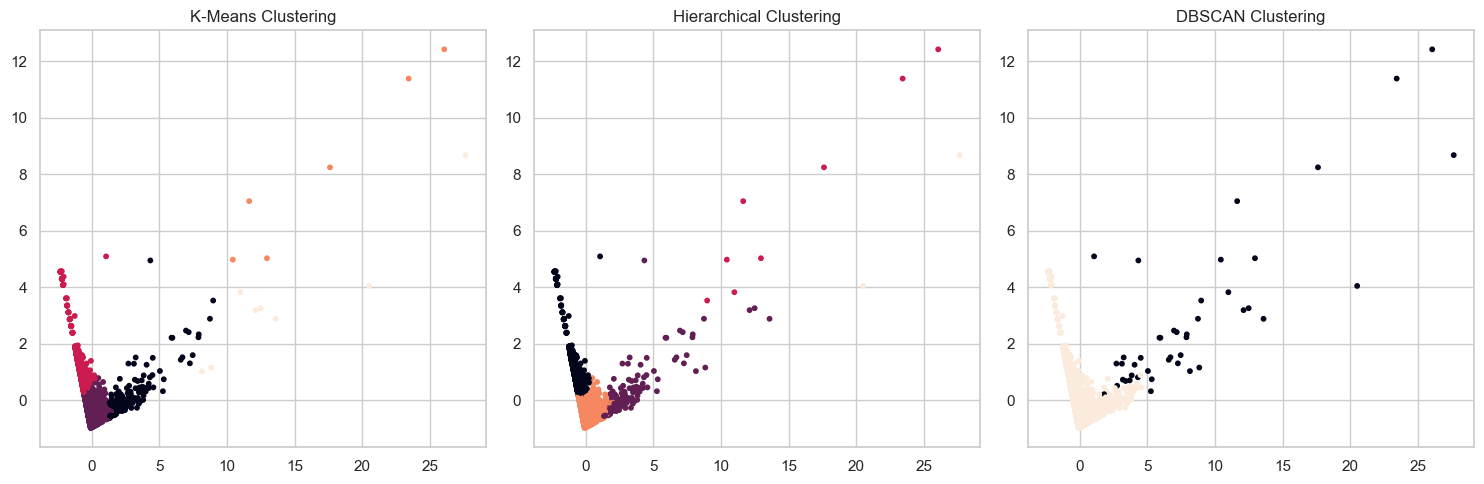

In [307]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


X = rfm_base[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(X_scaled)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hierarchical
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)


plt.figure(figsize=(15,5))

# K-Means
plt.subplot(1,3,1)
plt.scatter(pca_points[:,0], pca_points[:,1], c=kmeans_labels, s=10)
plt.title("K-Means Clustering")

# Hierarchical
plt.subplot(1,3,2)
plt.scatter(pca_points[:,0], pca_points[:,1], c=agg_labels, s=10)
plt.title("Hierarchical Clustering")

# DBSCAN
plt.subplot(1,3,3)
plt.scatter(pca_points[:,0], pca_points[:,1], c=db_labels, s=10)
plt.title("DBSCAN Clustering")

plt.tight_layout()
plt.savefig("clustering_model_comparison_600dpi.png", dpi=600)
plt.show()


DBSCAN identifies outlier customers with abnormal purchase behavior, complementing K-Means segmentation

FINAL CLUSTERING CONCLUSION:

K-Means clustering was selected as the final segmentation approach due to its interpretability and alignment with business-friendly RFM segments, while hierarchical clustering validated cluster structure and DBSCAN helped identify outlier customers.

🔷 STEP 8 — Target Variable Creation

In [308]:


def assign_rfm_segment(rfm_total):
    if rfm_total >= 13:
        return 'High Value'
    elif 10 <= rfm_total <= 12:
        return 'Loyal'
    elif 7 <= rfm_total <= 9:
        return 'Potential'
    elif 5 <= rfm_total <= 6:
        return 'At Risk'
    else:
        return 'Low Value'

# Apply function
rfm_scored['Customer_Value'] = rfm_scored['RFM_Total'].apply(assign_rfm_segment)

# Quick validation
rfm_scored['Customer_Value'].value_counts()


Customer_Value
Potential     1094
Loyal          992
High Value     950
At Risk        758
Low Value      544
Name: count, dtype: int64

In [309]:
rfm_scored[['Recency','Frequency','Monetary','RFM_Total','Customer_Value']].head()


,Recency,Frequency,Monetary,RFM_Total,Customer_Value
0,327,1,77183.60,7,Potential
1,41,7,4310.00,14,High Value
2,77,4,1797.24,11,Loyal
3,20,1,1757.55,9,Potential
4,312,1,334.40,4,Low Value


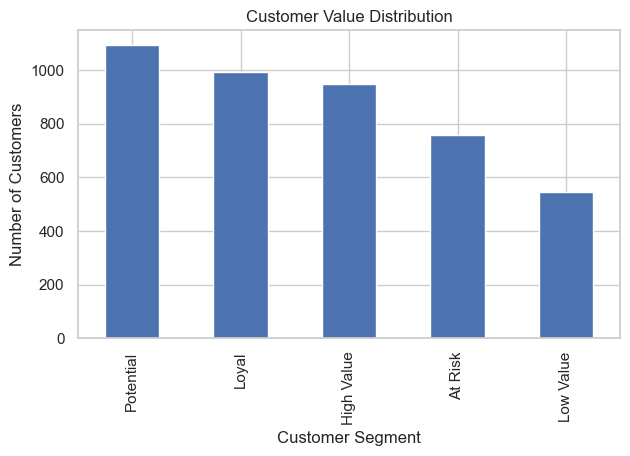

In [310]:
rfm_scored['Customer_Value'].value_counts().plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Customer Value Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()


In [311]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RecencyScore',
       'FrequencyScore', 'MonetaryScore', 'RFM_Total', 'Segment'],
      dtype='object')

In [312]:
rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,175.834967,1.352941,393.114183
High Value,19.979657,11.684154,6517.066478
Low Value,290.510972,1.037618,211.537539
Loyal,50.795019,3.844828,1625.130163
Potential,87.712613,1.905405,684.262153


Majority of customers fall into mid-value segments, highlighting strong upsell and retention opportunities.

🔷 Step 9 - Train-Test Split

9.1 Select Feature and Target

In [313]:
X = rfm_scored[['Recency', 'Frequency', 'Monetary']]
y = rfm_scored['Segment']


9.2 Encode Target Variable

In [314]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# View mapping
dict(zip(le.classes_, le.transform(le.classes_)))

{'At Risk': np.int64(0),
 'High Value': np.int64(1),
 'Low Value': np.int64(2),
 'Loyal': np.int64(3),
 'Potential': np.int64(4)}

9.3 Train-Test Split

In [315]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [316]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (3470, 3)
Testing samples: (868, 3)


FEATURE SCALING

In [317]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# -----------------------------
# Fit ONLY on training data
# -----------------------------
# Learns mean & standard deviation from training set
X_train_scaled = scaler.fit_transform(X_train)

# -----------------------------
# Transform test data
# -----------------------------
# Uses SAME scaling parameters
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Convert back to DataFrame (optional but useful)
# -----------------------------
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# -----------------------------
# Validation
# -----------------------------
print("Scaled Training Data (first 5 rows):")
print(X_train_scaled.head())


Scaled Training Data (first 5 rows):
       Recency  Frequency  Monetary
1221  0.266568  -0.288619 -0.163066
3227 -0.128682  -0.411519 -0.036498
1551 -0.638116   0.817477 -0.014377
2676 -0.910400   0.202979 -0.111531
1112 -0.409749  -0.411519 -0.105632


🔷 Step 10 - ML Model Training

10.1 - Encode target variables

In [318]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Convert text labels to numbers
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# View mapping (VERY IMPORTANT for explanation)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


{np.int64(0): np.int64(0),
 np.int64(1): np.int64(1),
 np.int64(2): np.int64(2),
 np.int64(3): np.int64(3),
 np.int64(4): np.int64(4)}

10.2 - Logistic Regression

In [319]:

from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train_enc)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)


10.3 Decision Tree Classifier

In [320]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


10.4 Random Forest

In [347]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

# Features & Target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# Save model & encoder
pickle.dump(model, open("rf_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Random Forest model saved successfully")

Random Forest model saved successfully


10.5 Support Vector Machine

In [322]:

from sklearn.svm import SVC

# Initialize model
svm_model = SVC(kernel='rbf')

# Train
svm_model.fit(X_train_scaled, y_train_enc)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)


🔷 Step 11 - Model Evaluation

11.1 — Create Evaluation Function

In [323]:

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')

    print(f"📌 Model: {model_name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print("-" * 40)

    return acc, prec


11.2 Evaluate all Models

In [324]:

results = []

results.append(("Logistic Regression", *evaluate_model(
    "Logistic Regression", y_test_enc, y_pred_log)))

results.append(("Decision Tree", *evaluate_model(
    "Decision Tree", y_test_enc, y_pred_dt)))

results.append(("Random Forest", *evaluate_model(
    "Random Forest", y_test_enc, y_pred_rf)))

results.append(("SVM", *evaluate_model(
    "SVM", y_test_enc, y_pred_svm)))


📌 Model: Logistic Regression
Accuracy  : 0.7488
Precision : 0.7362
----------------------------------------
📌 Model: Decision Tree
Accuracy  : 0.8975
Precision : 0.8925
----------------------------------------
📌 Model: Random Forest
Accuracy  : 0.9021
Precision : 0.8944
----------------------------------------
📌 Model: SVM
Accuracy  : 0.7961
Precision : 0.7816
----------------------------------------


11.3 Compare results in table

In [325]:


results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision"]
)

results_df.sort_values(by="Precision", ascending=False)


,Model,Accuracy,Precision
2,Random Forest,0.902074,0.894413
1,Decision Tree,0.897465,0.892455
3,SVM,0.796083,0.781587
0,Logistic Regression,0.748848,0.736208


In [326]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

    results_df = pd.DataFrame(results)
results_df




c:\Users\visha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.816820,0.814402,0.816820,0.811876
1,Decision Tree,0.983871,0.984229,0.983871,0.983932
2,Random Forest,0.987327,0.987435,0.987327,0.987324
3,Support Vector Machine,0.535714,0.695676,0.535714,0.500794


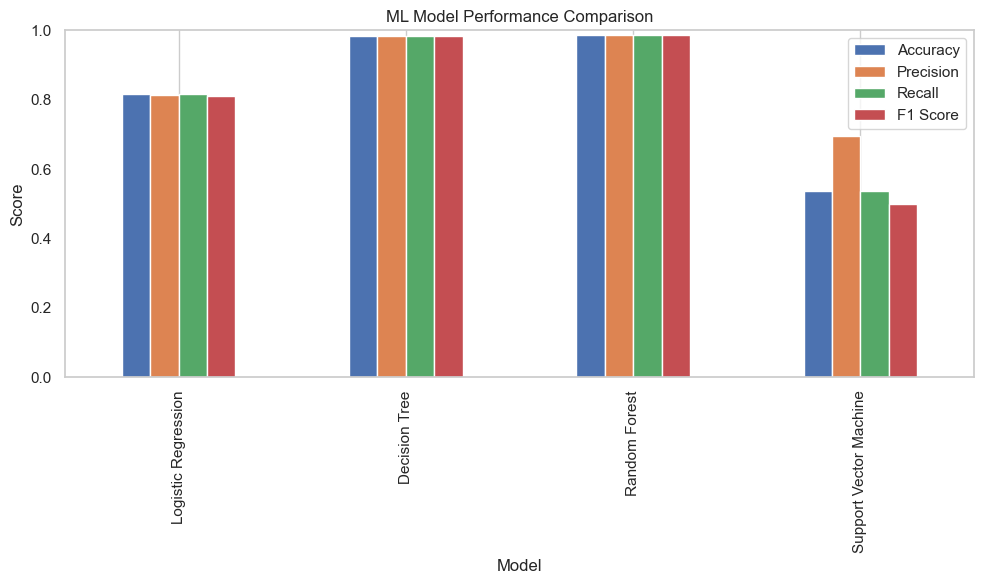

In [ ]:
import matplotlib.pyplot as plt 

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("ml_model_comparison_600dpi.png", dpi=600)
plt.show()


11.4 - Confusion Mareix - Random Forest

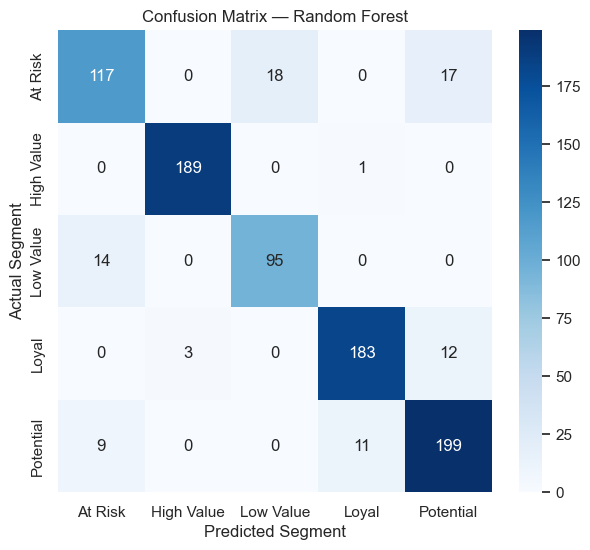

In [344]:

cm = confusion_matrix(y_test_enc, y_pred_rf)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")
plt.title("Confusion Matrix — Random Forest")
plt.show()


STEP 12: FINAL CONCLUSION

trained multiple machine learning models including Logistic Regression, Decision Tree, Random Forest, and SVM.

After evaluating them using accuracy, precision, and confusion matrices, Random Forest performed the best with the highest precision.

It handled non-linear customer behavior effectively and produced well-balanced predictions across all RFM segments.”

In [354]:
import pandas as pd

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_df

,Feature,Importance
0,Recency,0.415884
2,Monetary,0.320865
1,Frequency,0.263251


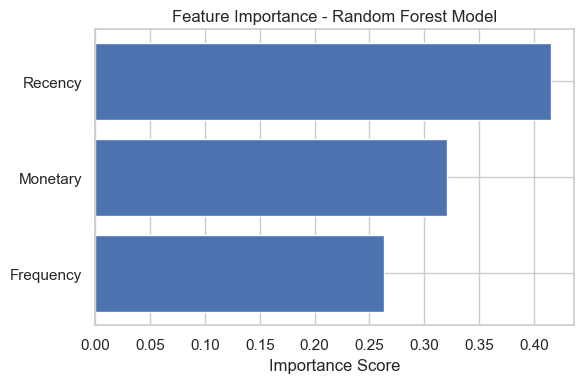

In [357]:
import matplotlib.pyplot as plt

feature_df = feature_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(6,4))
palette='Blues'
plt.barh(feature_df["Feature"], feature_df["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance - Random Forest Model")
plt.tight_layout()
plt.show()